<a href="https://colab.research.google.com/github/loopforger/data-science-Assignment-1/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You have been hired by a rookie movie producer to help him decide what type of movies to produce and which actors to cast. You have to back your recommendations based on thorough analysis of the data he shared with you which has the list of 3000 movies and the corresponding details.

 As a data scientist, you have to first explore the data and check its sanity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Data
df = pd.read_csv('imdb_data_1.csv')
print("Shape:", df.shape)
df.head()

# Sanity Check
print("Rows and Columns :", df.shape)
print("\nColumn Names :")
print(df.columns.tolist())

print("\nData Types :")
print(df.dtypes)

print("\nMissing Values :")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

df.describe()

Shape: (3000, 23)
Rows and Columns : (3000, 23)

Column Names :
['id', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue']

Data Types :
id                         int64
belongs_to_collection     object
budget                     int64
genres                    object
homepage                  object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity               float64
poster_path               object
production_companies      object
production_countries      object
release_date              object
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title    

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [ ]:
# Capitalize Column Names
df.columns = df.columns.str.capitalize()
print("Column names after capitalizing:")
print(df.columns.tolist())


# Clean Data
# Keep only movies where budget and revenue are greater than 0
df = df[df['Budget'] > 0]
df = df[df['Revenue'] > 0]

# Profit column
df['Profit'] = df['Revenue'] - df['Budget']

# ROI = (Profit / Budget) * 100
df['ROI'] = (df['Profit'] / df['Budget']) * 100

print("Rows after cleaning:", len(df))
print("\nSample:")
print(df[['Title', 'Budget', 'Revenue', 'Profit', 'ROI']].head())

Column names after capitalizing:
['Id', 'Belongs_to_collection', 'Budget', 'Genres', 'Homepage', 'Imdb_id', 'Original_language', 'Original_title', 'Overview', 'Popularity', 'Poster_path', 'Production_companies', 'Production_countries', 'Release_date', 'Runtime', 'Spoken_languages', 'Status', 'Tagline', 'Title', 'Keywords', 'Cast', 'Crew', 'Revenue']
Rows after cleaning: 2188

Sample:
                                      Title    Budget   Revenue    Profit  \
0                    Hot Tub Time Machine 2  14000000  12314651  -1685349   
1  The Princess Diaries 2: Royal Engagement  40000000  95149435  55149435   
2                                  Whiplash   3300000  13092000   9792000   
3                                   Kahaani   1200000  16000000  14800000   
5    Pinocchio and the Emperor of the Night   8000000   3261638  -4738362   

           ROI  
0   -12.038207  
1   137.873588  
2   296.727273  
3  1233.333333  
5   -59.229525  


In [ ]:
# Helper Functions
# We need ast.literal_eval() to convert strings in columns like Cast, Crew and Genres into a real Python list.
def get_names(value):
    # Converts stringified list into actual list of names
    try:
        items = ast.literal_eval(str(value))
        return [d['name'] for d in items if isinstance(d, dict) and 'name' in d]
    except:
        return []

def get_director(value):
    # Finds the person in Crew whose job is 'Director'
    try:
        items = ast.literal_eval(str(value))
        for person in items:
            if isinstance(person, dict) and person.get('job') == 'Director':
                return person.get('name')
    except:
        pass
    return None

def get_producer(value):
    # Finds the person in Crew whose job is 'Producer'
    try:
        items = ast.literal_eval(str(value))
        for person in items:
            if isinstance(person, dict) and person.get('job') == 'Producer':
                return person.get('name')
    except:
        pass
    return None


# Functions to create new columns
df['Actors']   = df['Cast'].apply(get_names)
df['Director'] = df['Crew'].apply(get_director)
df['Producer'] = df['Crew'].apply(get_producer)

# Remove rows where actor list is empty
df = df[df['Actors'].map(len) > 0]

print("Sample:")
print(df[['Title', 'Director', 'Producer']].head())

Sample:
                                      Title         Director         Producer
0                    Hot Tub Time Machine 2       Steve Pink     Andrew Panay
1  The Princess Diaries 2: Royal Engagement   Garry Marshall  Whitney Houston
2                                  Whiplash  Damien Chazelle  David Lancaster
3                                   Kahaani      Sujoy Ghosh      Sujoy Ghosh
5    Pinocchio and the Emperor of the Night   Hal Sutherland             None


Q1 : Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.

Title    : Furious 7
Budget   : $190,000,000
Revenue  : $1,506,249,360
Profit   : $1,316,249,360
ROI      : 692.76 %
Director : James Wan
Producer : Vin Diesel
Actors   : ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson', 'Michelle Rodriguez', 'Tyrese Gibson']


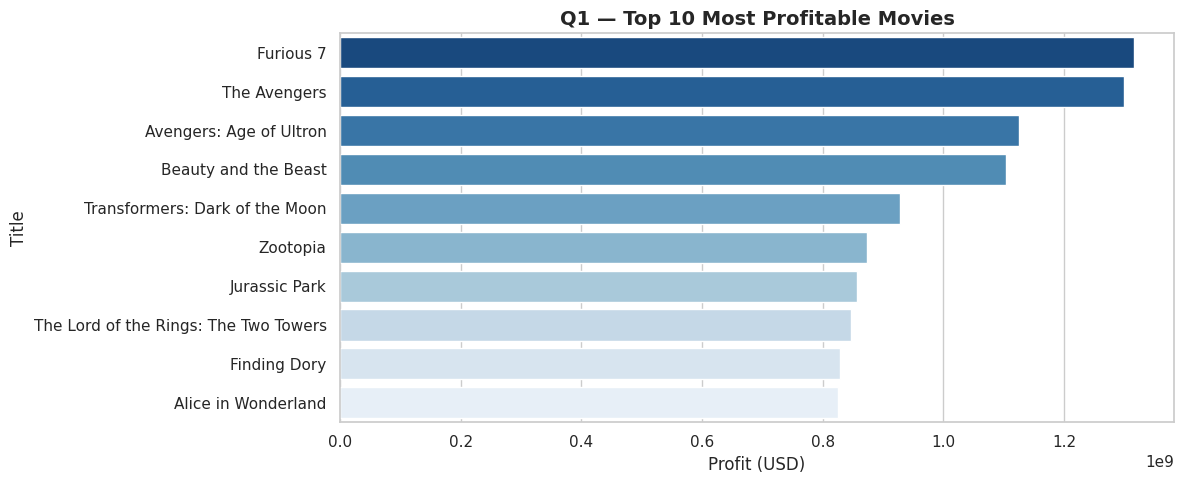

In [ ]:
# idxmax() gives the row index of the maximum Profit value
top = df.loc[df['Profit'].idxmax()]
print("Title    :", top['Title'])
print("Budget   : $" + f"{top['Budget']:,.0f}")
print("Revenue  : $" + f"{top['Revenue']:,.0f}")
print("Profit   : $" + f"{top['Profit']:,.0f}")
print("ROI      :", round(top['ROI'], 2), "%")
print("Director :", top['Director'])
print("Producer :", top['Producer'])
print("Actors   :", top['Actors'][:5])

top10 = df.nlargest(10, 'Profit')
plt.figure(figsize=(12, 5))
sns.barplot(x='Profit', y='Title', data=top10, palette='Blues_r')
plt.xlabel("Profit (USD)")
plt.title("Q1 — Top 10 Most Profitable Movies", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Q2 : Which language has the highest average ROI (return on investment)?



                        Avg_ROI  Num_Movies
Original_language                          
ko                 3.817941e+07          11
en                 5.482166e+05        1928
de                 4.349067e+02          11
zh                 4.084563e+02          14
es                 3.794217e+02          17
hi                 2.713313e+02          39
ta                 2.155159e+02          13
ja                 1.858405e+02          18
cn                 1.738661e+02           8
fr                 1.705117e+02          39

Winner : ko
Avg ROI: 38179410.23 %


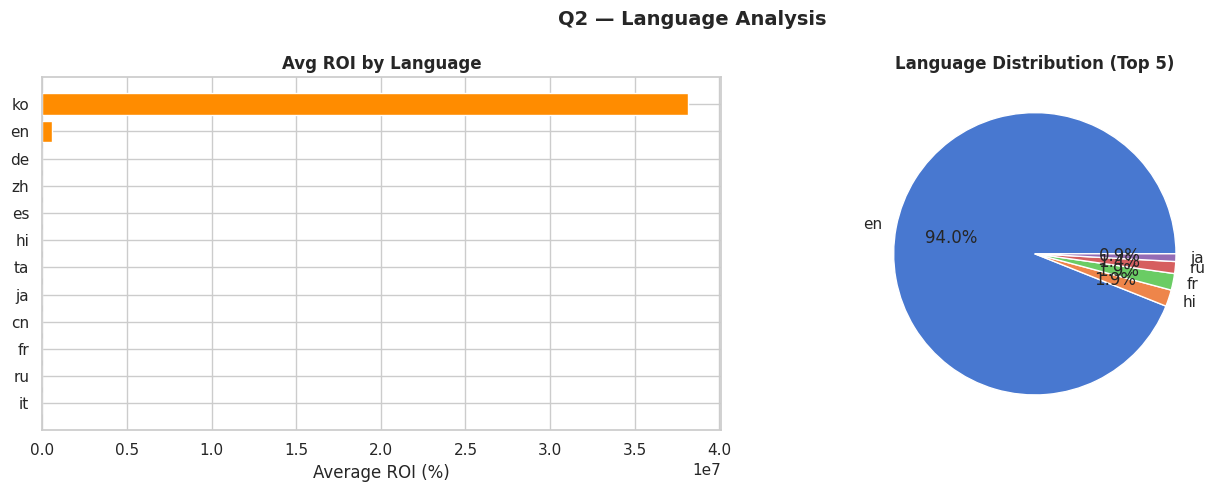

In [ ]:
# Group movies by language, calculate average ROI
# Keep only languages with at least 5 movies (more reliable result)

lang_roi = df.groupby('Original_language')['ROI'].agg(['mean', 'count'])
lang_roi.columns = ['Avg_ROI', 'Num_Movies']
lang_roi = lang_roi[lang_roi['Num_Movies'] >= 5]
lang_roi = lang_roi.sort_values('Avg_ROI', ascending=False)

print(lang_roi.head(10))
print("\nWinner :", lang_roi.index[0])
print("Avg ROI:", round(lang_roi.iloc[0]['Avg_ROI'], 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Bar chart: Avg ROI by language
plot_data = lang_roi.head(12).sort_values('Avg_ROI')
axes[0].barh(plot_data.index, plot_data['Avg_ROI'], color='darkorange')
axes[0].set_xlabel("Average ROI (%)")
axes[0].set_title("Avg ROI by Language", fontweight='bold')

# Chart 2 — Pie chart: Language distribution
lang_count = df['Original_language'].value_counts().head(5)
axes[1].pie(lang_count.values, labels=lang_count.index, autopct='%1.1f%%')
axes[1].set_title("Language Distribution (Top 5)", fontweight='bold')

plt.suptitle("Q2 — Language Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Q3 : Find out the unique genres of movies in this dataset.

Total unique genres: 20

All genres:
   1. Action
   2. Adventure
   3. Animation
   4. Comedy
   5. Crime
   6. Documentary
   7. Drama
   8. Family
   9. Fantasy
  10. Foreign
  11. History
  12. Horror
  13. Music
  14. Mystery
  15. Romance
  16. Science Fiction
  17. TV Movie
  18. Thriller
  19. War
  20. Western


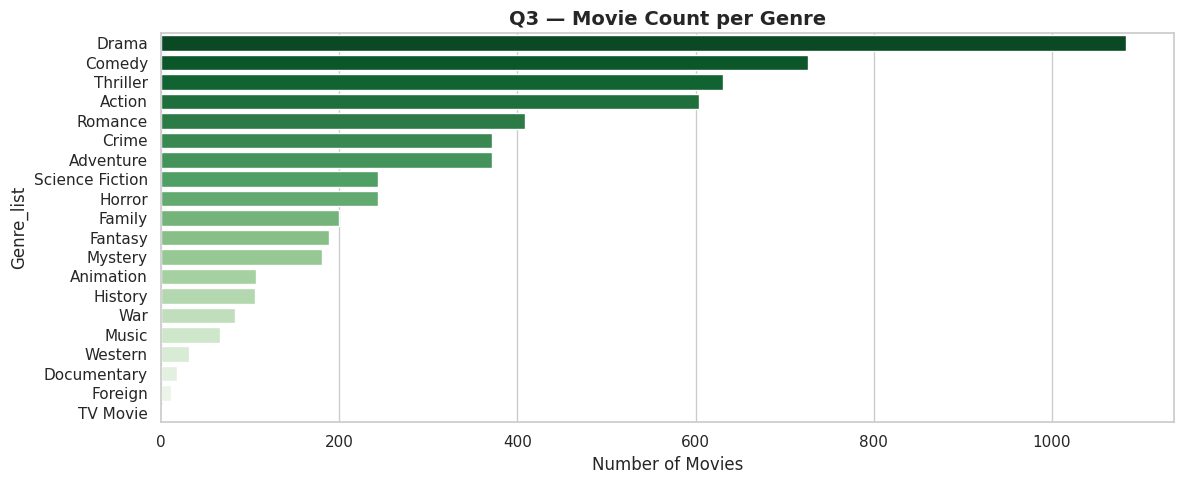

In [ ]:
# explode() splits the list so each genre gets its own row then we find all unique values
df['Genre_list'] = df['Genres'].apply(get_names)
genre_series  = df['Genre_list'].explode()
unique_genres = sorted(genre_series.dropna().unique())
genre_counts  = genre_series.value_counts()
print("Total unique genres:", len(unique_genres))
print("\nAll genres:")
for i, g in enumerate(unique_genres, 1):
    print(f"  {i:2}. {g}")

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Greens_r')
plt.xlabel("Number of Movies")
plt.title("Q3 — Movie Count per Genre", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Q4 : Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?

                                   Title          Director         Producer
                  Hot Tub Time Machine 2        Steve Pink     Andrew Panay
The Princess Diaries 2: Royal Engagement    Garry Marshall  Whitney Houston
                                Whiplash   Damien Chazelle  David Lancaster
                                 Kahaani       Sujoy Ghosh      Sujoy Ghosh
  Pinocchio and the Emperor of the Night    Hal Sutherland             None
                          The Possession      Ole Bornedal             None
                           A Mighty Wind Christopher Guest     Karen Murphy
                                   Rocky  John G. Avildsen    Irwin Winkler
                         American Beauty        Sam Mendes      Bruce Cohen
                                 Be Cool      F. Gary Gray     Danny DeVito
                         Minority Report  Steven Spielberg      Jan de Bont
                                Skinning Stevan Filipoviƒá Branislav Jeliƒá
            

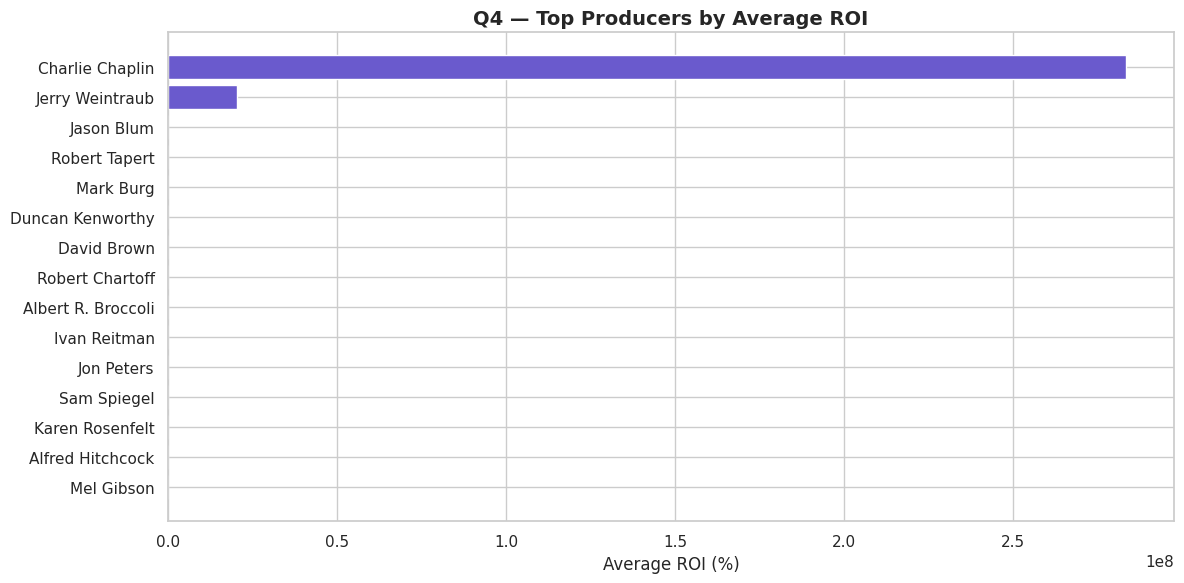

In [ ]:
print(df[['Title', 'Director', 'Producer']].head(15).to_string(index=False))
# groupby on Producer, then mean ROI, filter min 3 movies

producer_roi = (
    df.dropna(subset=['Producer'])
    .groupby('Producer')['ROI']
    .agg(['mean', 'count'])
)
producer_roi.columns = ['Avg_ROI', 'Num_Movies']
producer_roi = producer_roi[producer_roi['Num_Movies'] >= 3]
producer_roi = producer_roi.sort_values('Avg_ROI', ascending=False)

print("Top 3 Producers by Average ROI:")
print(producer_roi.head(3))

top15_prod = producer_roi.head(15).sort_values('Avg_ROI')
plt.figure(figsize=(12, 6))
plt.barh(top15_prod.index, top15_prod['Avg_ROI'], color='slateblue')
plt.xlabel("Average ROI (%)")
plt.title("Q4 — Top Producers by Average ROI", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Q5 : Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.

Actor        : Samuel L. Jackson
Total movies : 25

Movies featuring Samuel L. Jackson:
                                       Title     Profit         ROI
                                The Avengers 1299557910  590.708141
                     Avengers: Age of Ultron 1125403694  401.929891
                               Jurassic Park  857100000 1360.476190
Star Wars: Episode III - Revenge of the Sith  737000000  652.212389
         Captain America: The Winter Soldier  544766572  320.450925
                             The Incredibles  539442092  586.350100
Star Wars: Episode II - Attack of the Clones  529398328  441.165273
                           Coming to America  249752301  640.390515
                                      Jumper  137231186  161.448454
                               Patriot Games  133051587  295.670193

Genre breakdown for Samuel L. Jackson:
Genre_list
Action             16
Crime              12
Adventure          11
Thriller           10
Science Fiction     9
Dra

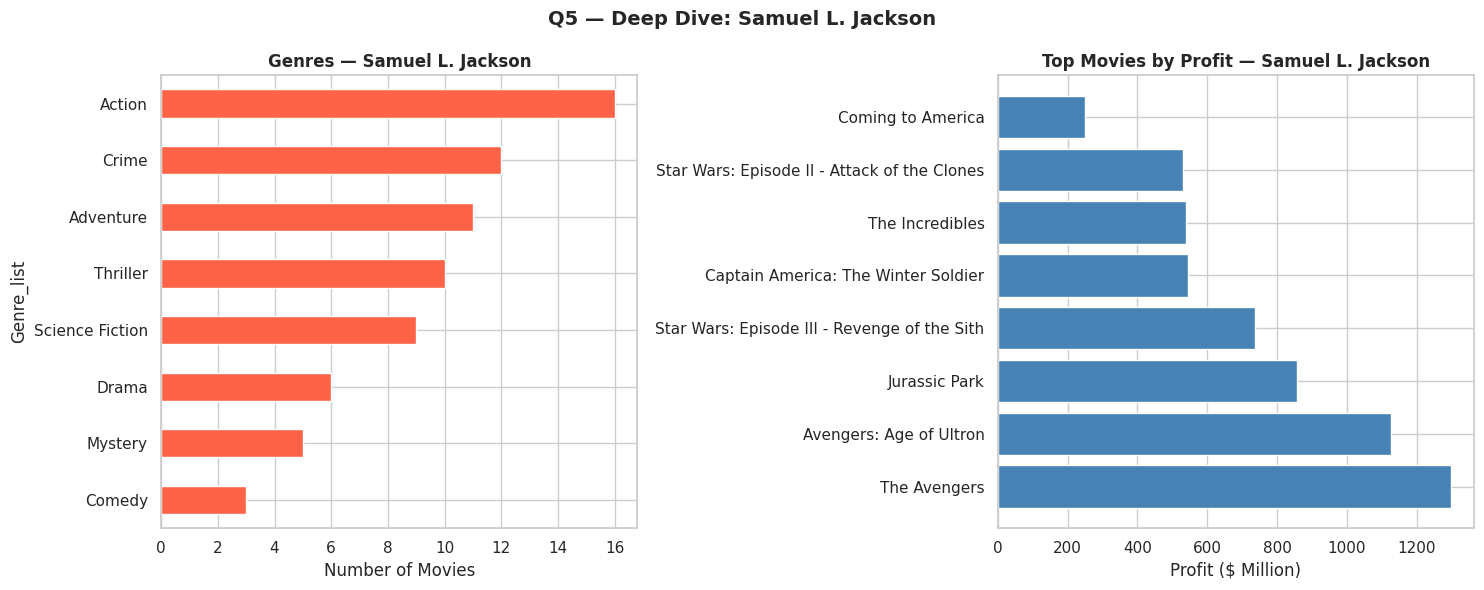

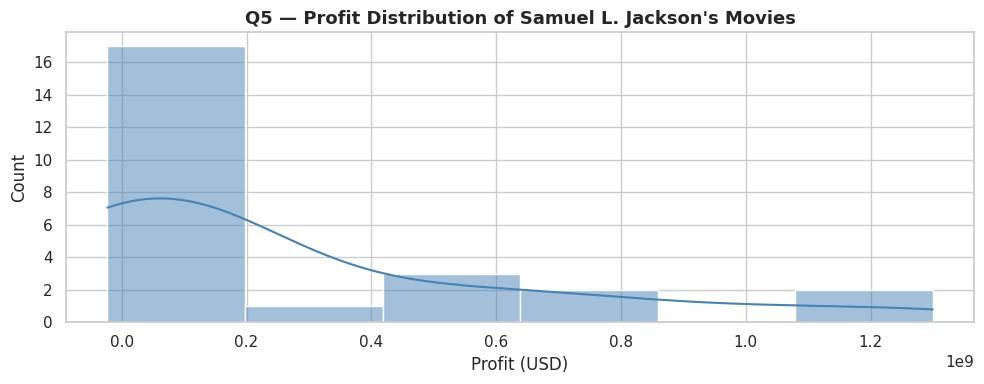

In [ ]:
all_actors   = df['Actors'].explode()
actor_counts = all_actors.value_counts()
top_actor    = actor_counts.index[0]
print("Actor        :", top_actor)
print("Total movies :", actor_counts.iloc[0])

# Filter all movies where this actor appeared
actor_movies = df[df['Actors'].apply(lambda x: top_actor in x)]

print(f"\nMovies featuring {top_actor}:")
print(actor_movies[['Title', 'Profit', 'ROI']].sort_values('Profit', ascending=False).head(10).to_string(index=False))

# Genre breakdown
actor_genres = actor_movies['Genre_list'].explode().value_counts()
print(f"\nGenre breakdown for {top_actor}:")
print(actor_genres.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1 — Genres
actor_genres.head(8).sort_values().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title(f"Genres — {top_actor}", fontweight='bold')
axes[0].set_xlabel("Number of Movies")

# Chart 2 — Top movies by profit
top_movies = actor_movies.nlargest(8, 'Profit')
axes[1].barh(top_movies['Title'], top_movies['Profit'] / 1e6, color='steelblue')
axes[1].set_xlabel("Profit ($ Million)")
axes[1].set_title(f"Top Movies by Profit — {top_actor}", fontweight='bold')

plt.suptitle(f"Q5 — Deep Dive: {top_actor}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Histogram shows how the profits of this actor's movies are spread
plt.figure(figsize=(10, 4))
sns.histplot(actor_movies['Profit'], kde=True, color='steelblue')
plt.xlabel("Profit (USD)")
plt.title(f"Q5 — Profit Distribution of {top_actor}'s Movies", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Q6 : Top 3 directors prefer which actors the most?

Top 3 Directors: ['Steven Spielberg', 'Clint Eastwood', 'Ron Howard']

🎬 Steven Spielberg:
Actors
Harrison Ford       3
Pat Roach           2
Tom Hanks           2
Richard Dreyfuss    2
Steven Spielberg    2

🎬 Clint Eastwood:
Actors
Clint Eastwood     6
Annie O'Donnell    2
Laura Linney       2
Mara Corday        2
Sondra Locke       2

🎬 Ron Howard:
Actors
Clint Howard    4
Rance Howard    3
Tom Hanks       2
Gary Sinise     2
James Ritz      2


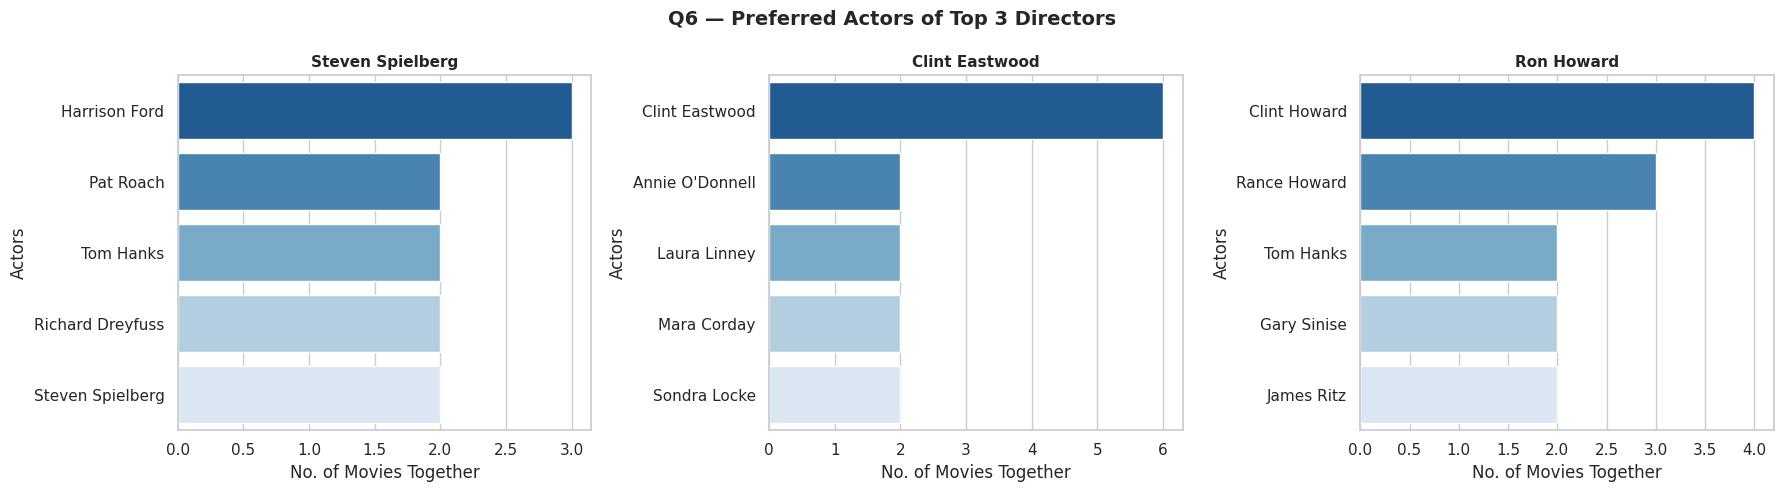

In [ ]:
# Using movie count (most movies directed) — simple and clear
top_directors = df['Director'].value_counts().head(3).index.tolist()
print("Top 3 Directors:", top_directors)
for director in top_directors:
    subset = df[df['Director'] == director]
    actors = subset['Actors'].explode().value_counts().head(5)
    print(f"\n🎬 {director}:")
    print(actors.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, director in enumerate(top_directors):
    subset = df[df['Director'] == director]
    actors = subset['Actors'].explode().value_counts().head(5)

    sns.barplot(x=actors.values, y=actors.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(director, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("No. of Movies Together")

plt.suptitle("Q6 — Preferred Actors of Top 3 Directors", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()